## load & import

In [1]:
!pip install pypokerengine treys

## Simplifying Assumptions (Phase 1)

- **Heads-up only:** 2 players (agent vs. rule-based opponent)
- **Agent always acts second (in position):** the opponent's action is always observed before the agent decides, so Pot Odds = 0 unambiguously means the opponent checked
- **Fixed opponent strategy:** opponent follows a deterministic rule-based policy, making the environment stationary
- **No all-in:** maximum bet is capped at 1× pot to keep the action space bounded

### State Space (1,152 states = 9 × 3 × 4 × 4 × 3)

| Dimension | Values | Description |
|---|---|---|
| **Hand Type** | 0–8 | High Card / One Pair / Two Pair / Three of a Kind / Straight / Flush / Full House / Four of a Kind | Straight Flush 
| **Hand Strength** | 0–2 | Low / Mid / High — kicker strength within hand type |
| **Betting Round** | 0–3 | Preflop / Flop / Turn / River |
| **Pot Odds** | 0–3 | 0 (opponent checked) / Low / Medium / High — opponent's bet relative to pot |
| **Pot Size** | 0–2 | Small / Medium / Large — pot relative to agent's stack |

> **Note:** The opponent's hole cards are unobservable. Community card content is implicitly captured by Hand Type and Betting Round.

### Action Space (5 actions)

| Index | Action | Description |
|---|---|---|
| 0 | **Fold** | Forfeit the hand, lose chips committed |
| 1 | **Check** | Pass when no bet is facing the agent (Pot Odds = 0) |
| 2 | **Call** | Match the opponent's bet |
| 3 | **Small Bet** | Raise to ~1/2 pot |
| 4 | **Big Bet** | Raise to ~1 pot |

> Bet sizes are fixed pot multiples to preserve tabular tractability.

In [2]:
# config for state and action space
from pypokerengine.api.game import setup_config, start_poker
from pypokerengine.players import BasePokerPlayer

# Action indices
FOLD      = 0
CHECK     = 1
CALL      = 2
SMALL_BET = 3
BIG_BET   = 4

# State space dimensions
N_HAND_TYPE     = 9  # HC / 1P / 2P / 3oaK / Straight / Flush / FH / 4oaK / SF+Royal
N_HAND_STRENGTH = 3  # Low / Mid / High (relative rank within hand type)
N_STREET        = 4  # preflop / flop / turn / river
N_POT_ODDS      = 4  # 0=check / Low / Mid / High
N_POT_SIZE      = 3  # Small / Medium / Large
STATE_SIZE  = N_HAND_TYPE * N_HAND_STRENGTH * N_STREET * N_POT_ODDS * N_POT_SIZE  # 1296
ACTION_SIZE = 5

STREET_MAP = {'preflop': 0, 'flop': 1, 'turn': 2, 'river': 3}

print(f"State space: {STATE_SIZE}, Action space: {ACTION_SIZE}")


State space: 1296, Action space: 5


### state encoding

In [3]:
def encode_state(hand_type, hand_strength, street, pot_odds, pot_size):
    return (hand_type    * N_HAND_STRENGTH * N_STREET * N_POT_ODDS * N_POT_SIZE
            + hand_strength * N_STREET * N_POT_ODDS * N_POT_SIZE
            + street        * N_POT_ODDS * N_POT_SIZE
            + pot_odds      * N_POT_SIZE
            + pot_size)

def decode_state(idx):
    pot_size      = idx % N_POT_SIZE;      idx //= N_POT_SIZE
    pot_odds      = idx % N_POT_ODDS;      idx //= N_POT_ODDS
    street        = idx % N_STREET;        idx //= N_STREET
    hand_strength = idx % N_HAND_STRENGTH; idx //= N_HAND_STRENGTH
    hand_type     = idx
    return hand_type, hand_strength, street, pot_odds, pot_size

# Sanity check
for idx in [0, 100, 500, 1000, STATE_SIZE - 1]:
    decoded = decode_state(idx)
    assert encode_state(*decoded) == idx, f"Failed at idx={idx}"
print(f"encode/decode OK  (STATE_SIZE={STATE_SIZE})")


encode/decode OK  (STATE_SIZE=1296)


## Hand Evaluation


In [4]:
from treys import Card, Evaluator
evaluator = Evaluator()

SUIT_MAP = {'S': 's', 'H': 'h', 'D': 'd', 'C': 'c'}

def parse_cards(card_strs):
    """pypokerengine format -> treys card int"""
    result = []
    for c in card_strs:
        suit = SUIT_MAP[c[0]]
        rank = c[1]
        result.append(Card.new(rank + suit))
    return result

# treys rank class (0-9) -> our hand type (0-8)
# rank_class 0: Royal Flush (score=1, treys quirk)
# rank_class 1: Straight Flush (incl. Royal Flush, scores 1-10)
# Both map to hand_type 8 (SF/Royal)
RANK_CLASS_MAP = {
    0: 8,  # Royal Flush (treys returns rank_class=0 for score=1)
    1: 8,  # Straight Flush (excl. Royal Flush)
    2: 7,  # Four of a Kind
    3: 6,  # Full House
    4: 5,  # Flush
    5: 4,  # Straight
    6: 3,  # Three of a Kind
    7: 2,  # Two Pair
    8: 1,  # One Pair
    9: 0,  # High Card
}

# Score range per rank class (for computing hand_strength within type)
# treys: score 1 = best (Royal Flush), 7462 = worst (High Card 7-5-4-3-2)
RANK_CLASS_RANGE = {
    0: (1,    10),    # Royal Flush (rank_class=0, score always 1)
    1: (1,    10),    # Straight Flush (excl. Royal Flush, scores 2-10)
    2: (11,   166),   # Four of a Kind
    3: (167,  322),   # Full House
    4: (323,  1599),  # Flush
    5: (1600, 1609),  # Straight
    6: (1610, 2467),  # Three of a Kind
    7: (2468, 3325),  # Two Pair
    8: (3326, 6185),  # One Pair
    9: (6186, 7462),  # High Card
}

def evaluate_hand(hole_card, community_card):
    hole  = parse_cards(hole_card)
    board = parse_cards(community_card)

    if len(board) == 0:
        # Preflop: only 2 cards, evaluator needs >= 5
        # hand_type: pair (1) or high card (0)
        # hand_strength: based on high card rank (0-12)
        ranks = sorted([Card.get_rank_int(c) for c in hole], reverse=True)
        hand_type = 1 if ranks[0] == ranks[1] else 0
        high = ranks[0]
        if high <= 4:
            hand_strength = 0
        elif high <= 9:
            hand_strength = 1
        else:
            hand_strength = 2
        return hand_type, hand_strength

    score      = evaluator.evaluate(board, hole)
    rank_class = evaluator.get_rank_class(score)
    hand_type  = RANK_CLASS_MAP[rank_class]

    # hand_strength: relative rank within this hand type
    # lower score = stronger hand, so invert before bucketing
    lo, hi = RANK_CLASS_RANGE[rank_class]
    normalized = (hi - score) / (hi - lo + 1)
    if normalized < 0.33:
        hand_strength = 0   # Low
    elif normalized < 0.66:
        hand_strength = 1   # Mid
    else:
        hand_strength = 2   # High

    return hand_type, hand_strength

# Sanity checks
print(evaluate_hand(['SA', 'SK'], ['HQ', 'DJ', 'CT']))  # Straight  -> (4, ?)
print(evaluate_hand(['SA', 'SK'], []))                   # Preflop AA -> (1, 2)
print(evaluate_hand(['D2', 'H7'], ['SA', 'CK', 'HQ']))  # High card -> (0, ?)
print(evaluate_hand(['SA', 'HA'], ['DA', 'CA', 'SK']))  # Four Aces -> (7, ?)  not 8
print(evaluate_hand(['SA', 'SK'], ['HA', 'HK', 'HQ', 'HJ', 'HT']))  # Royal Flush -> (8, ?)


(4, 2)
(0, 2)
(0, 2)
(7, 2)
(8, 2)


In [5]:
def get_pot_odds(valid_actions, pot_amount):
    """
    Return discretized pot-odds bucket (0=opponent checked, 1=low, 2=mid, 3=high).
    0 = opponent checked (call amount is 0)
    1 = Low  (call/pot < 0.5)
    2 = Mid  (0.5 <= call/pot < 1.0)
    3 = High (call/pot >= 1.0)
    """
    call_amount = valid_actions[1]['amount']
    
    if call_amount == 0:
        return 0  # Opponent checked
    
    if pot_amount == 0:
        return 1  # Avoid division by zero
    
    ratio = call_amount / pot_amount
    if ratio < 0.5:
        return 1  # Lower than half pot
    elif ratio < 1.0:
        return 2  # Medium
    else:
        return 3  # Higher than pot


def get_pot_size(pot_amount, agent_stack):
    """
    Return discretized pot-size bucket relative to agent's stack (0=small, 1=medium, 2=large).
        0 = Small  (pot/stack < 0.1)
    1 = Medium (0.1 <= pot/stack < 0.3)
    2 = Large  (pot/stack >= 0.3)
    0 = Small  (pot/stack < 0.1)
    1 = Medium (0.1 <= pot/stack < 0.3)
    2 = Large  (pot/stack >= 0.3)
    """
    if agent_stack == 0:
        return 2
    
    ratio = pot_amount / agent_stack
    if ratio < 0.1:
        return 0  # Small
    elif ratio < 0.3:
        return 1  # Medium
    else:
        return 2  # Large

In [6]:
# Opponent decision matrix: OPPONENT_MATRIX[hand_type][hand_strength] -> aggression level
#   0 = passive  : no bet facing -> check;  bet facing -> fold
#   1 = neutral  : no bet facing -> check;  bet facing -> call
#   2 = aggressive: no bet facing -> bet;   bet facing -> call
#
#              Str=Low  Str=Mid  Str=High
OPPONENT_MATRIX = [
    [0, 0, 1],   # 0: High Card    — only high-strength high card calls
    [1, 1, 2],   # 1: One Pair     — low/mid pair calls, high pair bets
    [1, 2, 2],   # 2: Two Pair     — mid/high two pair bets
    [1, 2, 2],   # 3: Three of a Kind
    [2, 2, 2],   # 4: Straight     — all straights and above bet
    [2, 2, 2],   # 5: Flush
    [2, 2, 2],   # 6: Full House
    [2, 2, 2],   # 7: Four of a Kind
    [2, 2, 2],   # 8: Straight Flush / Royal Flush
]

class RuleBasedOpponent(BasePokerPlayer):
    """
    Rule-based opponent using a 9x3 (hand_type x hand_strength) decision matrix.
    Works uniformly across all streets including preflop.
    """
    def declare_action(self, valid_actions, hole_card, round_state):
        community_card = round_state['community_card']
        hand_type, hand_strength = evaluate_hand(hole_card, community_card)

        call_amount = valid_actions[1]['amount']
        raise_info  = valid_actions[2]['amount']
        raise_min   = raise_info['min']
        raise_max   = raise_info['max']
        pot_amount  = round_state['pot']['main']['amount']

        level = OPPONENT_MATRIX[hand_type][hand_strength]

        if level == 0:                          # passive
            if call_amount > 0:
                return 'fold', 0
            else:
                return 'call', 0                # check
        elif level == 1:                        # neutral
            return 'call', call_amount          # call or check
        else:                                   # aggressive
            if call_amount == 0:
                amount = max(raise_min, min(int(pot_amount * 0.5), raise_max))
                return 'raise', amount          # bet half pot
            else:
                return 'call', call_amount      # call (no re-raise for simplicity)

    def receive_game_start_message(self, game_info): pass
    def receive_round_start_message(self, round_count, hole_card, seats): pass
    def receive_street_start_message(self, street, round_state): pass
    def receive_game_update_message(self, action, round_state): pass
    def receive_round_result_message(self, winners, hand_info, round_state): pass


### Reward Function

| Outcome | Reward |
|---|---|
| Win | +P (pot size at conclusion) |
| Lose or Fold | −C (chips committed by agent this round) |
| Intermediate steps | 0 |

> Rewards are issued at the conclusion of each round (upon fold or showdown).


In [7]:
class PokerAgent(BasePokerPlayer):
    def __init__(self, policy_fn=None):
        super().__init__()
        self.policy_fn = policy_fn or (lambda state, valid_actions: 2)
        self.episode_log = []
        self._chips_start = None
        self._current_hole = None

    def receive_game_start_message(self, game_info):
        pass

    def receive_round_start_message(self, round_count, hole_card, seats):
        self._current_hole = hole_card
        self.episode_log = []
        for s in seats:
            if s['name'] == 'agent':
                self._chips_start = s['stack']

    def receive_street_start_message(self, street, round_state):
        pass

    def receive_game_update_message(self, action, round_state):
        pass

    def receive_round_result_message(self, winners, hand_info, round_state):
        for s in round_state['seats']:
            if s['name'] == 'agent':
                chips_end = s['stack']
        reward = chips_end - self._chips_start

        if self.episode_log:
            s, a, _ = self.episode_log[-1]
            self.episode_log[-1] = (s, a, reward)
        elif self._current_hole is not None:
            # Opponent folded preflop before agent acted — reward is lost without this.
            # Synthesize a preflop state (pot_odds=0, pot_size=0) with action CHECK
            # so training algorithms receive the positive "free win" signal.
            hand_type, hand_strength = evaluate_hand(self._current_hole, [])
            state = encode_state(hand_type, hand_strength, 0, 0, 0)
            self.episode_log.append((state, CHECK, reward))

    def declare_action(self, valid_actions, hole_card, round_state):
        community_card = round_state['community_card']
        pot_amount     = round_state['pot']['main']['amount']
        street         = STREET_MAP[round_state['street']]

        agent_stack = 1000
        for s in round_state['seats']:
            if s['name'] == 'agent':
                agent_stack = s['stack']

        hand_type, hand_strength = evaluate_hand(hole_card, community_card)
        pot_odds = get_pot_odds(valid_actions, pot_amount)
        pot_size = get_pot_size(pot_amount, agent_stack)

        state = encode_state(hand_type, hand_strength, street, pot_odds, pot_size)
        action_idx = self.policy_fn(state, valid_actions)
        action_str, amount = self._translate_action(action_idx, valid_actions, pot_amount)

        self.episode_log.append((state, action_idx, 0))
        return action_str, amount

    def _translate_action(self, action_idx, valid_actions, pot_amount):
        call_amount = valid_actions[1]['amount']
        raise_min   = valid_actions[2]['amount']['min']
        raise_max   = valid_actions[2]['amount']['max']

        if action_idx == 0:
            return 'fold', 0
        elif action_idx == 1:
            if call_amount == 0:
                return 'call', 0
            else:
                return 'call', call_amount
        elif action_idx == 2:
            return 'call', call_amount
        elif action_idx == 3:
            amount = max(raise_min, min(int(pot_amount * 0.5), raise_max))
            return 'raise', amount
        elif action_idx == 4:
            amount = max(raise_min, min(int(pot_amount * 1.0), raise_max))
            return 'raise', amount
        else:
            return 'call', call_amount


In [8]:
def run_single_hand(agent, stack, small_blind=10, verbose=0):
    """
    Run a single poker hand with a given starting stack.
    Returns (episode_log, ending_stack).
    """
    opponent = RuleBasedOpponent()
    config = setup_config(
        max_round=1,
        initial_stack=stack,
        small_blind_amount=small_blind
    )
    # Opponent registers first = small blind = acts first
    # Agent registers second  = big blind  = acts second (in position)
    config.register_player(name='opponent', algorithm=opponent)
    config.register_player(name='agent',    algorithm=agent)
    start_poker(config, verbose=verbose)
    # Recover ending stack from agent
    ending_stack = agent._chips_start + (agent.episode_log[-1][2] if agent.episode_log else 0)
    return agent.episode_log


def run_episode(agent_factory, n_hands=20, initial_stack=1000, small_blind=10):
    """
    Run a full episode consisting of n_hands sequential poker hands.
    Stack persists across hands within an episode.
    Episode ends early if stack reaches 0.

    agent_factory: callable () -> PokerAgent  (creates a fresh agent each hand)
    Returns: combined episode_log across all hands, list of (state, action, reward)
    """
    stack       = initial_stack
    full_log    = []

    for hand_num in range(n_hands):
        if stack <= small_blind * 2:
            break  # Cannot post blinds — episode over

        agent = agent_factory()
        log   = run_single_hand(agent, stack, small_blind)

        if log:
            reward = log[-1][2]   # chip gain/loss this hand
            stack += reward
            stack  = max(stack, 0)
            full_log.extend(log)

    return full_log


# Smoke test
test_log = run_episode(lambda: PokerAgent(), n_hands=20)
print(f"Episode steps: {len(test_log)}")
print(f"Total reward:  {sum(r for _,_,r in test_log if r != 0)}")
print("run_episode OK")


Episode steps: 50
Total reward:  280
run_episode OK


## Training Process (the whole version is 2500 episodes total 50000 hands, here also for faster check)

In [10]:
import numpy as np
np.random.seed(42)

ALPHA       = 0.1
GAMMA       = 0.95
EPSILON_START    = 0.05
EPSILON_END     = 0.01
N_EPISODES  = 250
EPSILON_DECAY = (EPSILON_END / EPSILON_START) ** (1 / N_EPISODES)

def get_valid_action_indices(valid_actions):
    call_amount = valid_actions[1]['amount']
    indices = [0, 2, 3, 4]   # fold, call, small bet, big bet always valid
    if call_amount == 0:
        indices.append(1)    # check only valid when no bet
    return indices

def epsilon_greedy(state, valid_actions, Q,epsilon):
    valid_idx = get_valid_action_indices(valid_actions)

    if np.random.random() < epsilon:
        return np.random.choice(valid_idx)

    # If every Q value is exactly 0 (completely unvisited state),
    # choose randomly from non-fold actions instead of defaulting to fold.
    # This breaks the "all-zeros → fold → never explore" deadlock.
    if all(Q[state, i] == 0.0 for i in valid_idx):
        non_fold = [i for i in valid_idx if i != FOLD]
        return np.random.choice(non_fold)

    q_valid = {idx: Q[state, idx] for idx in valid_idx}
    return max(q_valid, key=q_valid.get)


In [11]:
def train_sarsa(n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START, n_hands=20):
    Q = np.zeros((STATE_SIZE, ACTION_SIZE))
    reward_history = []

    for ep in range(n_episodes):
        log = run_episode(
            lambda: PokerAgent(policy_fn=lambda s, va: epsilon_greedy(s, va, Q, epsilon)),
            n_hands=n_hands
        )

        # SARSA update: Q(s,a) += alpha * [r + gamma * Q(s',a') - Q(s,a)]
        for i in range(len(log) - 1):
            s, a, r = log[i]
            s_next, a_next, _ = log[i + 1]
            Q[s, a] += alpha * (r + gamma * Q[s_next, a_next] - Q[s, a])

        # Terminal step
        if log:
            s, a, r = log[-1]
            Q[s, a] += alpha * (r - Q[s, a])

        episode_reward = sum(r for _, _, r in log if r != 0)
        reward_history.append(episode_reward)

        if (ep + 1) % 100 == 0:
            avg = np.mean(reward_history[-100:])
            print(f"Episode {ep+1}, Avg reward (last 100): {avg:.2f}")

    return Q, reward_history


In [12]:
def train_qlearning(n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START, n_hands=20):
    Q = np.zeros((STATE_SIZE, ACTION_SIZE))
    reward_history = []

    for ep in range(n_episodes):
        log = run_episode(
            lambda: PokerAgent(policy_fn=lambda s, va: epsilon_greedy(s, va, Q, epsilon)),
            n_hands=n_hands
        )

        # Q-learning update: Q(s,a) += alpha * [r + gamma * max Q(s',a) - Q(s,a)]
        for i in range(len(log) - 1):
            s, a, r = log[i]
            s_next, _, _ = log[i + 1]
            Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])

        # Terminal step
        if log:
            s, a, r = log[-1]
            Q[s, a] += alpha * (r - Q[s, a])

        episode_reward = sum(r for _, _, r in log if r != 0)
        reward_history.append(episode_reward)

        if (ep + 1) % 100 == 0:
            avg = np.mean(reward_history[-100:])
            print(f"Episode {ep+1}, Avg reward (last 100): {avg:.2f}")

    return Q, reward_history


In [13]:
def train_mc_afterstate(n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START, n_hands=20):
    """
    Monte Carlo with After State value function V(S).
    V(S) is updated via discounted returns (first-visit MC).
    Q_mc_sum/cnt track average returns per (S,A) for action selection.
    """
    V        = np.zeros(STATE_SIZE)
    Q_mc_sum = np.zeros((STATE_SIZE, ACTION_SIZE))
    Q_mc_cnt = np.zeros((STATE_SIZE, ACTION_SIZE))
    reward_history = []

    for ep in range(n_episodes):
        def mc_policy(s, va):
            valid_idx = get_valid_action_indices(va)
            if np.random.random() < epsilon:
                return np.random.choice(valid_idx)
            non_fold = [i for i in valid_idx if i != FOLD]
            if not any(Q_mc_cnt[s, i] > 0 for i in non_fold):
                return np.random.choice(non_fold)
            best, best_val = valid_idx[0], -np.inf
            for i in valid_idx:
                val = Q_mc_sum[s, i] / Q_mc_cnt[s, i] if Q_mc_cnt[s, i] > 0 else 0.0
                if val > best_val:
                    best_val = val
                    best = i
            return best

        log = run_episode(lambda: PokerAgent(policy_fn=mc_policy), n_hands=n_hands)

        if not log:
            reward_history.append(0)
            continue

        # First-visit MC: compute discounted returns backward
        visited_sa = set()
        G = 0
        for t in reversed(range(len(log))):
            s, a, r = log[t]
            G = r + gamma * G
            # After State update: V(S) += alpha * (G - V(S))
            V[s] += alpha * (G - V[s])
            if (s, a) not in visited_sa:
                visited_sa.add((s, a))
                Q_mc_sum[s, a] += G
                Q_mc_cnt[s, a] += 1

        episode_reward = sum(r for _, _, r in log if r != 0)
        reward_history.append(episode_reward)

        if (ep + 1) % 100 == 0:
            avg = np.mean(reward_history[-100:])
            print(f"Episode {ep+1}, Avg reward (last 100): {avg:.2f}")

    return V, Q_mc_sum, Q_mc_cnt, reward_history


## Run All Training

In [14]:
print("=== Training SARSA ===")
Q_sarsa, history_sarsa = train_sarsa()

print("\n=== Training Q-Learning ===")
Q_qlearn, history_qlearn = train_qlearning()

print("\n=== Training MC After State ===")
V_mc, Q_mc_sum, Q_mc_cnt, history_mc = train_mc_afterstate()

print("\nAll training complete.")


=== Training SARSA ===
Episode 100, Avg reward (last 100): -176.00
Episode 200, Avg reward (last 100): -59.30

=== Training Q-Learning ===
Episode 100, Avg reward (last 100): -82.40
Episode 200, Avg reward (last 100): -40.50

=== Training MC After State ===
Episode 100, Avg reward (last 100): 101.60
Episode 200, Avg reward (last 100): 207.00

All training complete.


## Evaluation

In [16]:
def evaluate_agent(policy_fn, n_episodes=100, n_hands=20):
    rewards = []
    wins    = 0
    for _ in range(n_episodes):
        log = run_episode(lambda: PokerAgent(policy_fn=policy_fn), n_hands=n_hands)
        r   = sum(reward for _, _, reward in log if reward != 0)
        rewards.append(r)
        if r > 0:
            wins += 1
    return np.mean(rewards), wins / n_episodes


def random_policy(s, va):
    return np.random.choice(get_valid_action_indices(va))

def _non_fold_fallback(valid_idx):
    return 1 if 1 in valid_idx else 2

def sarsa_greedy(s, va):
    valid_idx = get_valid_action_indices(va)
    if all(Q_sarsa[s, i] == 0.0 for i in valid_idx):
        return _non_fold_fallback(valid_idx)
    return max(valid_idx, key=lambda i: Q_sarsa[s, i])

def qlearn_greedy(s, va):
    valid_idx = get_valid_action_indices(va)
    if all(Q_qlearn[s, i] == 0.0 for i in valid_idx):
        return _non_fold_fallback(valid_idx)
    return max(valid_idx, key=lambda i: Q_qlearn[s, i])

def mc_greedy(s, va):
    valid_idx = get_valid_action_indices(va)
    non_fold  = [i for i in valid_idx if i != FOLD]
    if not any(Q_mc_cnt[s, i] > 0 for i in non_fold):
        return _non_fold_fallback(valid_idx)
    best, best_val = valid_idx[0], -np.inf
    for i in valid_idx:
        val = Q_mc_sum[s, i] / Q_mc_cnt[s, i] if Q_mc_cnt[s, i] > 0 else 0.0
        if val > best_val:
            best_val, best = val, i
    return best


N_EVAL = 100
print(f"Evaluating over {N_EVAL} episodes each (20 hands/episode)...\n")

eval_policies = [
    ("Random",        random_policy),
    ("SARSA",         sarsa_greedy),
    ("Q-Learning",    qlearn_greedy),
    ("MC AfterState", mc_greedy),
]

results = {}
for name, policy in eval_policies:
    avg_r, win_rate = evaluate_agent(policy, N_EVAL)
    results[name] = (avg_r, win_rate)
    print(f"{name:16s}  avg reward: {avg_r:+.2f}  win rate: {win_rate:.1%}")


Evaluating over 100 episodes each (20 hands/episode)...

Random            avg reward: -196.70  win rate: 38.0%
SARSA             avg reward: +234.60  win rate: 70.0%
Q-Learning        avg reward: -16.50  win rate: 53.0%
MC AfterState     avg reward: +299.30  win rate: 89.0%


In [17]:
# ── Strategy table: what does each agent do at River, facing various contexts?
# Rows: hand_type × hand_strength  |  Cols: two contexts (no bet vs facing bet)
# Context A: river, pot_odds=0 (no bet), pot_size=1 (medium)
# Context B: river, pot_odds=2 (medium bet), pot_size=1 (medium)

HAND_TYPE_NAMES = ['HC', '1P', '2P', '3oaK', 'Str', 'Flush', 'FH', '4oaK', 'SF/R']
HAND_STR_NAMES  = ['Low', 'Mid', 'High']
ACTION_NAMES    = ['Fold', 'Check', 'Call', 'SBet', 'BBet']

# dummy valid_actions for two contexts
def _dummy_va(call_amount):
    return [
        {'action': 'fold',  'amount': 0},
        {'action': 'call',  'amount': call_amount},
        {'action': 'raise', 'amount': {'min': 20, 'max': 500}},
    ]

VA_NOBET  = _dummy_va(0)   # opponent checked → check valid
VA_MIDBET = _dummy_va(50)  # opponent bet 50 → check invalid

print("=" * 72)
print(f"{'Strategy Table — River (pot_size=Medium)'}")
print(f"{'Hand':>10}  {'Str':>4}  "
      f"{'SARSA(no bet)':>13}  {'SARSA(facing bet)':>17}  "
      f"{'QL(no bet)':>10}  {'QL(facing bet)':>14}  "
      f"{'MC(no bet)':>10}  {'MC(facing bet)':>14}")
print("-" * 110)

for ht in range(N_HAND_TYPE):
    for hs in range(N_HAND_STRENGTH):
        state_nb = encode_state(ht, hs, 3, 0, 1)   # river, no bet,  medium pot
        state_mb = encode_state(ht, hs, 3, 2, 1)   # river, mid bet, medium pot

        s_nb  = ACTION_NAMES[sarsa_greedy(state_nb,  VA_NOBET)]
        s_mb  = ACTION_NAMES[sarsa_greedy(state_mb,  VA_MIDBET)]
        ql_nb = ACTION_NAMES[qlearn_greedy(state_nb, VA_NOBET)]
        ql_mb = ACTION_NAMES[qlearn_greedy(state_mb, VA_MIDBET)]
        mc_nb = ACTION_NAMES[mc_greedy(state_nb,     VA_NOBET)]
        mc_mb = ACTION_NAMES[mc_greedy(state_mb,     VA_MIDBET)]

        print(f"{HAND_TYPE_NAMES[ht]:>10}  {HAND_STR_NAMES[hs]:>4}  "
              f"{s_nb:>13}  {s_mb:>17}  "
              f"{ql_nb:>10}  {ql_mb:>14}  "
              f"{mc_nb:>10}  {mc_mb:>14}")
    print()

# ── Also check preflop states (only HC/1P possible) ──────────────────────────
print("=" * 72)
print("Preflop spot (SB calls → agent sees no bet, small pot)")
print(f"{'Hand':>10}  {'Str':>4}  {'SARSA':>8}  {'Q-Learn':>8}  {'MC':>8}")
print("-" * 50)
for ht in range(2):   # only HC, 1P at preflop
    for hs in range(N_HAND_STRENGTH):
        state = encode_state(ht, hs, 0, 0, 0)   # preflop, no bet, small pot
        print(f"{HAND_TYPE_NAMES[ht]:>10}  {HAND_STR_NAMES[hs]:>4}  "
              f"{ACTION_NAMES[sarsa_greedy(state, VA_NOBET)]:>8}  "
              f"{ACTION_NAMES[qlearn_greedy(state, VA_NOBET)]:>8}  "
              f"{ACTION_NAMES[mc_greedy(state, VA_NOBET)]:>8}")


Strategy Table — River (pot_size=Medium)
      Hand   Str  SARSA(no bet)  SARSA(facing bet)  QL(no bet)  QL(facing bet)  MC(no bet)  MC(facing bet)
--------------------------------------------------------------------------------------------------------------
        HC   Low           Call               Call        Fold            Call       Check            Call
        HC   Mid           Call               Call        Call            Call       Check            Call
        HC  High           Call               Call        Call            Call       Check            Call

        1P   Low          Check               Call        Call            Call        Fold            Call
        1P   Mid           Fold               Call       Check            Call       Check            Call
        1P  High           Fold               Call        Call            Call       Check            Call

        2P   Low          Check               Call        Call            Call        Fold       

## Learning Curves & Results

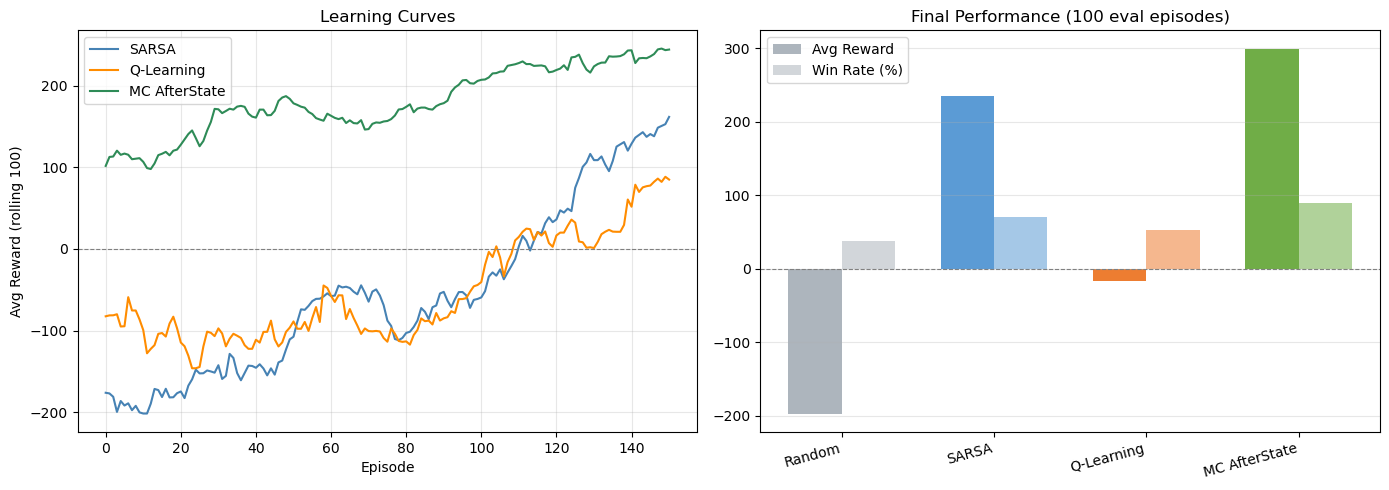

Saved → multi_results.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Learning curves (rolling mean) ----
ax = axes[0]
WINDOW = 100
COLORS = {'SARSA': 'steelblue', 'Q-Learning': 'darkorange', 'MC AfterState': 'seagreen'}

for name, hist in [('SARSA', history_sarsa), ('Q-Learning', history_qlearn), ('MC AfterState', history_mc)]:
    smoothed = np.convolve(hist, np.ones(WINDOW) / WINDOW, mode='valid')
    ax.plot(smoothed, label=name, color=COLORS[name], linewidth=1.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel(f'Avg Reward (rolling {WINDOW})')
ax.set_title('Learning Curves')
ax.legend()
ax.grid(alpha=0.3)

# ---- Right: Bar chart of final evaluation ----
ax2 = axes[1]
names     = list(results.keys())
avg_rwds  = [results[n][0] for n in names]
win_rates = [results[n][1] * 100 for n in names]
bar_colors = ['#adb5bd', '#5b9bd5', '#ed7d31', '#70ad47']

x, w = np.arange(len(names)), 0.35
ax2.bar(x - w/2, avg_rwds,  w, label='Avg Reward',   color=bar_colors)
ax2.bar(x + w/2, win_rates, w, label='Win Rate (%)', color=bar_colors, alpha=0.55)

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=15, ha='right')
ax2.set_title(f'Final Performance ({N_EVAL:,} eval episodes)')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('multi_results.png', dpi=300)
plt.show()
print("Saved → multi_results.png")
